# Downloading Pre-trained models

In [ ]:
import wget
url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
SHAPE_PREDICTOR = wget.download(url)
print(SHAPE_PREDICTOR)

In [25]:
import bz2
SHAPE_PREDICTOR="shape_predictor_68_face_landmarks.dat.bz2"
with bz2.open(SHAPE_PREDICTOR,"rb")as f:
    decompressed = f.read()
with open("shape_predictor_68_face_landmarks.dat","wb")as f:
    f.write(decompressed)

In [ ]:
import wget
model_url = r"http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2"
model = wget.download(model_url)
print(model)

In [26]:
import bz2
model = "dlib_face_recognition_resnet_model_v1.dat.bz2"
with bz2.open(model,"rb")as f:
    decompressed_model = f.read()
with open("dlib_face_recognition_resnet_model_v1.dat","wb")as f:
    f.write(decompressed_model)

# Importing Modules

In [27]:
import cv2
import numpy as np
import os
import time
import dlib
from imutils.video import VideoStream
from imutils import face_utils
from imutils.face_utils import FaceAligner
import urllib.request
import pickle
import csv
import shutil
from random import shuffle
import urllib.request
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras import utils
from tensorflow.keras.callbacks import ModelCheckpoint
from keras import backend as K
from keras.models import load_model
from imutils.video import VideoStream
import keras

# Tryig to add Current User's Face images for training (Not needed as we have certain set of images)

In [5]:
DIR = "faces/"
MODEL = "dlib_face_recognition_resnet_model_v1.dat"
SHAPE_PREDICTOR = "shape_predictor_68_face_landmarks.dat"
detector = dlib.get_frontal_face_detector()
shape_predictor = dlib.shape_predictor(SHAPE_PREDICTOR)
face_aligner = FaceAligner(shape_predictor, desiredFaceWidth=250)

def create_dir(name):
    if not os.path.exists(name):
        os.mkdir(name)


create_dir(name=DIR)

print("[INFO] Preparing to prepare dataset")

while True:
    face_id = input("[Input] Enter ID for face: ")
    try:
        face_id = face_id
        face_dir = DIR + str(face_id) + "/"
        create_dir(face_dir)
        print("[INFO] Directory created to store your dataset")
        break

    except:
        print("[Info] Invalid Input. ID must be an integer")
        continue

print("[INFO] starting video stream...")
vs = VideoStream(src=0).start()
total_imgs = 0

# Get Face Images
while True:
    frame = vs.read()
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(frame_gray)

    if len(faces) == 1:
        face = faces[0]
        (x, y, w, h) = face_utils.rect_to_bb(face)
        face_img = frame_gray[y:y+h, x:x+w]
        face_align = face_aligner.align(frame, frame_gray, face)

        face_img = face_align
        key = cv2.waitKey(1) & 0xFF
        if key == ord("k"):
            save_img_path = face_dir + str(total_imgs) + ".png"
            cv2.imwrite(save_img_path, face_img)
            total_imgs += 1
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 255, 0), 3)
        cv2.imshow("Aligned", face_img)

    cv2.imshow("Preparing Dataset", frame)
    key = cv2.waitKey(1) & 0xFF
    cv2.waitKey(1)

    if key == ord("q"):
        break
    elif total_imgs == 300:
        break


print("[INFO] {} face images stored".format(total_imgs))
print("[INFO] cleaning up...")
cv2.destroyAllWindows()
vs.stop()

[INFO] Preparing to prepare dataset
[INFO] Directory created to store your dataset
[INFO] starting video stream...


TypeError: Can't parse 'center'. Sequence item with index 0 has a wrong type

: 

# Stopping the video stream

In [ ]:
vs.stop()

# Converting all the images present in the face folder into certain feature vectors and storing those values in a csv file (dataset.csv)

In [28]:
MODEL = "dlib_face_recognition_resnet_model_v1.dat"
SHAPE_PREDICTOR = "shape_predictor_68_face_landmarks.dat"
INITIAL_FACES = "faces/"
FACE_DATASET = 'dataset_faces/'
CSV_FILE = "dataset.csv"

def create_folder(folder_name):
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)

def csv_to_pickel(csv_file):
    print("\n[INFO] Initiating CSV to pickle conversion\n")
    features = []
    labels = []
    with open(csv_file, newline="") as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            labels.append(int(row[0]))
            features.append(np.array(row[1:], dtype=np.float32))
    
    no_of_faces = len(features)
    train_features = features[:int(0.9*no_of_faces)]
    train_labels = labels[:int(0.9*no_of_faces)]
    
    test_features = features[int(0.9*no_of_faces):]
    test_labels = labels[int(0.9*no_of_faces):]
    
    print("\t[INFO] Length of train_features: ", len(train_features))
    with open('train_features', 'wb') as f:
        pickle.dump(train_features, f)
    # del train_features
    
    print("\t[INFO] Length of train_labels: ", len(train_labels))
    with open('train_labels', 'wb') as f:
        pickle.dump(train_labels, f)
    # del train_labels
    
    print("\t[INFO] Length of test_features: ", len(test_features))
    with open('test_features', 'wb') as f:
        pickle.dump(test_features, f)
    # del test_features
    
    print("\t[INFO] Length of test_labels: ", len(test_labels))
    with open('test_labels', 'wb') as f:
        pickle.dump(test_labels, f)
    # del test_labels


print("\n[INFO] Initiating to store facial features...\n")

face_rec = dlib.face_recognition_model_v1(MODEL)
shape_predictor = dlib.shape_predictor(SHAPE_PREDICTOR)
detector = dlib.get_frontal_face_detector()

create_folder(FACE_DATASET)

folder_names = os.listdir(INITIAL_FACES)
face_descriptors = []
row = ""
folder_count = 0
for folder_name in folder_names:
    folder_count += 1
    create_folder(FACE_DATASET+folder_name)
    full_folder_path = INITIAL_FACES+folder_name+"/"
    print("[INFO] Storing facial features of folder " + str(folder_count) + "/" + str(len(folder_names)))

    images = os.listdir(full_folder_path)
    print(images)
    image_count = 0
    errors = 0
    success = 0
    for image in images:
        image_count += 1
        full_image_path = full_folder_path+image
        print(full_image_path)
        print(str(folder_count) + "/" + str(len(folder_names)) + "\t[INFO] Working with " + str(image_count) + "/" + str(len(images)))
        img = cv2.imread(full_image_path)
        cv2.imwrite(FACE_DATASET+folder_name+"/"+image, img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        try:
            face = detector(img, 1)[0]
            print("\t\t[INFO] Success.!")
            success += 1
        except:
            print("\t\t[INFO] Error.!")
            errors += 1
            continue
        shape = shape_predictor(img, face)
        face_descriptor = face_rec.compute_face_descriptor(img, shape)
        face_descriptor = list(face_descriptor)
        face_descriptor.insert(0, int(folder_name))
        with open(CSV_FILE, "a", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(face_descriptor)
        print("Successful Encoded : " + str(success) + "| Error while Encoding : " + str(errors))
#     shutil.rmtree(full_folder_path)
# shutil.rmtree(INITIAL_FACES)

print("[INFO] cleaning up...")

with open(CSV_FILE) as f:
    li = f.readlines()

shuffle(li)
shuffle(li)
shuffle(li)
with open(CSV_FILE, 'w') as f:
    f.writelines(li)

print("[INFO] Facial Features successfully stored in " + str(CSV_FILE) + "...")

csv_to_pickel(CSV_FILE) #Unnecessary Function we have handled it in next block of code



[INFO] Initiating to store facial features...

[INFO] Storing facial features of folder 1/52
['Achchutan S _1.jpg', 'Achchutan S _6.jpg', 'Achchutan S _2.jpg', 'Achchutan S _5.jpg', 'Achchutan S _0.jpg', 'Achchutan S _3.jpg', 'Achchutan S _7.jpg', 'Achchutan S _4.jpg']
faces/124003008/Achchutan S _1.jpg
1/52	[INFO] Working with 1/8
		[INFO] Success.!
Successful Encoded : 1| Error while Encoding : 0
faces/124003008/Achchutan S _6.jpg
1/52	[INFO] Working with 2/8
		[INFO] Success.!
Successful Encoded : 2| Error while Encoding : 0
faces/124003008/Achchutan S _2.jpg
1/52	[INFO] Working with 3/8
		[INFO] Success.!
Successful Encoded : 3| Error while Encoding : 0
faces/124003008/Achchutan S _5.jpg
1/52	[INFO] Working with 4/8
		[INFO] Success.!
Successful Encoded : 4| Error while Encoding : 0
faces/124003008/Achchutan S _0.jpg
1/52	[INFO] Working with 5/8
		[INFO] Success.!
Successful Encoded : 5| Error while Encoding : 0
faces/124003008/Achchutan S _3.jpg
1/52	[INFO] Working with 6/8
		[IN

# From the feature vectors we have got from previous step we are train the model using MLP Classifier and plotting the accuracy and loss over iterations

### (The first column is taken as the label and rest all columns as features from the dataset file)

401
401
52
360
360
41
41
You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/100


/home/yugendran-sunder/Documents/Face Liveness Detection at Edge Computing Paper/New version/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 3.9920 

2025-07-12 18:16:10.476299: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_209', 72 bytes spill stores, 72 bytes spill loads

2025-07-12 18:16:11.168681: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_209', 4 bytes spill stores, 4 bytes spill loads

2025-07-12 18:16:11.712223: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_209', 224 bytes spill stores, 256 bytes spill loads

2025-07-12 18:16:12.216016: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_209', 468 bytes spill stores, 468 bytes spill loads



23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.0000e+00 - loss: 3.9907
Epoch 1: accuracy improved from -inf to 0.00000, saving model to mlp_model_keras2.h5


...

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9160 - loss: 0.2722 - val_accuracy: 0.8293 - val_loss: 0.6270
Epoch 17/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9375 - loss: 0.0913
Epoch 17: accuracy improved from 0.93889 to 0.96389, saving model to mlp_model_keras2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9636 - loss: 0.0925 - val_accuracy: 0.8049 - val_loss: 0.7903
Epoch 18/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.2153
Epoch 18: accuracy did not improve from 0.96389
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9600 - loss: 0.1074 - val_accuracy: 0.7073 - val_loss: 0.7189
Epoch 19/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8125 - loss: 0.3492
Epoch 19: accuracy did not improve from 0.96389
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9271 - loss: 0.2079 - val_accuracy: 0.8049 - val_loss: 0.7740
Epoch 20/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0684
Epoch 20: accuracy did not improve from 0.96389
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9613 - loss: 0.1153 - val_accuracy: 0.7805 - val_loss: 0.8657
Epoch 21/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0501
Epoch 21: accuracy did not improve from 0.96389


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9830 - loss: 0.0687 - val_accuracy: 0.8293 - val_loss: 0.6610
Epoch 27/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0226
Epoch 27: accuracy improved from 0.98611 to 0.99444, saving model to mlp_model_keras2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9960 - loss: 0.0170 - val_accuracy: 0.8293 - val_loss: 0.5804
Epoch 28/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0383
Epoch 28: accuracy improved from 0.99444 to 1.00000, saving model to mlp_model_keras2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 0.8293 - val_loss: 0.5933
Epoch 29/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 5.6151e-04
Epoch 29: accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8537 - val_loss: 0.6479
Epoch 30/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 9.4188e-04
Epoch 30: accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8537 - val_loss: 0.6185
Epoch 31/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 8.8070e-04
Epoch 31: accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 9.0312e-04 - val_accuracy: 0.8537 - val_loss: 0.6015
Epoch 32/100
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 32: accuracy did not impro

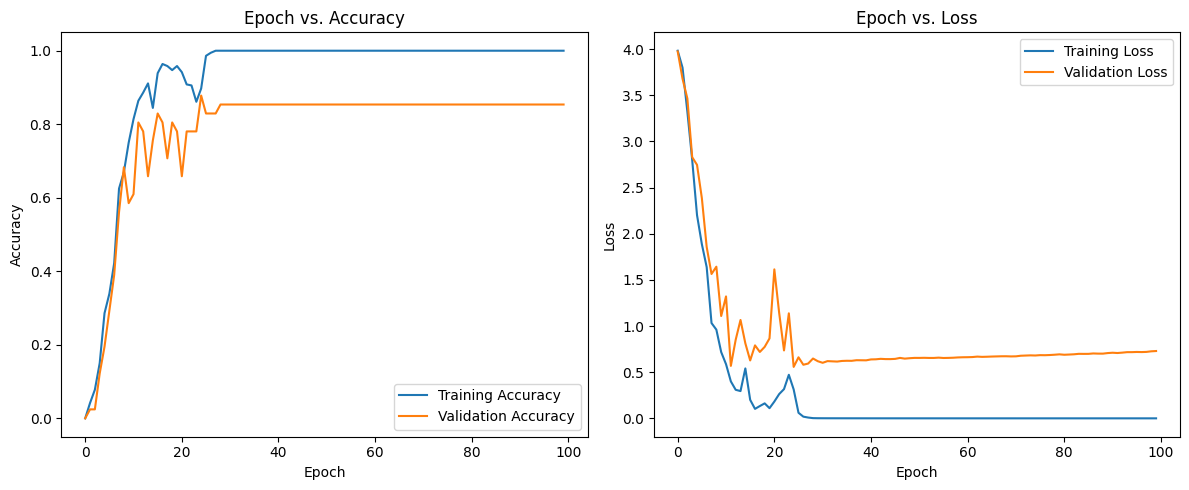

In [24]:
import matplotlib.pyplot as plt
import csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import ModelCheckpoint
from keras import optimizers, utils
from sklearn.preprocessing import LabelEncoder
import keras

# Set image data format
keras.backend.set_image_data_format('channels_last')
CSV_FILE = "dataset.csv"

# Function to inspect labels
def inspect_labels(labels):
    unique_labels = np.unique(labels)
    print("Unique labels:", unique_labels)
    print("Number of unique labels:", len(unique_labels))
    return len(unique_labels)

# Function to re-encode labels to a contiguous range
def encode_labels(labels):
    encoder = LabelEncoder()
    encoded_labels = encoder.fit_transform(labels)
    return encoded_labels, len(encoder.classes_)

# Define the MLP model
def mlp_model(train_labels):
    num_of_faces = train_labels.shape[1]
    model = Sequential()
    model.add(Dense(128, input_shape=(128,), activation='relu'))
    # model.add(Dropout(0.8))
    model.add(Dense(256, activation='relu'))
    # model.add(Dropout(0.8))
    model.add(Dense(1024, activation='relu'))
    # model.add(Dropout(0.8))
    model.add(Dense(num_of_faces, activation='softmax'))
    
    adam = optimizers.Adam(learning_rate=1e-2)
    model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
    
    # Model checkpoint
    filepath = "mlp_model_keras2.h5"
    checkpoint1 = ModelCheckpoint(filepath, monitor='accuracy', verbose=1, save_best_only=True, mode='max')
    callbacks_list = [checkpoint1]
    
    from keras.utils import plot_model
    plot_model(model, to_file='model.png', show_shapes=True)
    return model, callbacks_list

# Training function
def train():
    features = []
    labels = []
    
    # Load dataset and assign features and labels based on the first column
    with open(CSV_FILE, newline="") as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            label = int(row[0])      # Label from unique ID column
            feature = np.array(row[1:], dtype=np.float32)  # Features (remaining columns)
            labels.append(label)
            features.append(feature)

    # Convert lists to numpy arrays
    all_features = np.array(features)
    all_labels = np.array(labels)
    print(len(all_features))
    print(len(all_labels))
    # Re-encode labels to ensure they are contiguous
    all_labels, num_classes = encode_labels(all_labels)
    print(num_classes)
    
    # Split the dataset (90% training, 10% testing)
    no_of_samples = len(all_features)
    train_images = all_features[:int(0.9 * no_of_samples)]
    train_labels = all_labels[:int(0.9 * no_of_samples)]
    test_images = all_features[int(0.9 * no_of_samples):]
    test_labels = all_labels[int(0.9 * no_of_samples):]

    print(len(train_images))
    print(len(train_labels))
    print(len(test_images))
    print(len(test_labels))
    
    # Convert labels to categorical
    train_labels = utils.to_categorical(train_labels, num_classes=num_classes)
    test_labels = utils.to_categorical(test_labels, num_classes=num_classes)
    
    # Build and train the model
    model, callbacks_list = mlp_model(train_labels)
    history = model.fit(train_images, train_labels, validation_data=(test_images, test_labels),
                        epochs=100, batch_size=16, callbacks=callbacks_list)

    # Evaluate model
    scores = model.evaluate(test_images, test_labels, verbose=3)
    print("MLP Error: %.2f%%" % (100 - scores[1] * 100))
    
    # Plot epoch vs. accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Epoch vs. Accuracy')
    plt.legend()
    
    # Plot epoch vs. loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Epoch vs. Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Run the training
train()


## We observe that the accuracy tends to be constant after ceratin iterations

# To predict the current user's face

In [28]:
detector = dlib.get_frontal_face_detector()
MODEL = "dlib_face_recognition_resnet_model_v1.dat"
SHAPE_PREDICTOR = "shape_predictor_68_face_landmarks.dat"
face_rec = dlib.face_recognition_model_v1(MODEL)
shape_predictor = dlib.shape_predictor(SHAPE_PREDICTOR)
face_recognizer = load_model('mlp_model_keras2.h5')

def recognize_face(face_descriptor):
    # print(face_descriptor)
    pred = face_recognizer.predict(face_descriptor)
    pred_probab = pred[0]
    pred_class = list(pred_probab).index(max(pred_probab))
    return max(pred_probab), pred_class
'''
def get_face_names():
	face_ids = dict()
	import sqlite3
	conn = sqlite3.connect("face_db.db")
	sql_cmd = "SELECT * FROM faces"
	cursor = conn.execute(sql_cmd)
	for row in cursor:
		face_ids[row[0]] = row[1]
	return face_ids
'''
def extract_face_info(img, img_rgb):
    faces = detector(img_rgb)
    x, y, w, h = 0, 0, 0, 0
    face_descriptor = None
    if len(faces) > 0:
        for face in faces:
            shape = shape_predictor(img, face)
            (x, y, w, h) = face_utils.rect_to_bb(face)
            cv2.rectangle(img, (x, y), (x+w, y+h), (255, 255, 0), 2)
            face_descriptor = face_rec.compute_face_descriptor(img_rgb, shape)
            face_descriptor = np.array([face_descriptor, ])
            probability, face_id = recognize_face(face_descriptor)
            if probability > 0.9:
                cv2.putText(img, "FaceId #"+str(face_id), (x, y - 70),
                            cv2.FONT_HERSHEY_PLAIN, 1.5, (0, 255, 0), 2)
                #cv2.putText(img, 'Name - '+face_names[face_id],  (x, y - 40), cv2.FONT_HERSHEY_PLAIN, 1.5, (0, 255, 0), 2)
                cv2.putText(img, "%s %.2f%%" % ('Probability', probability*100),
                            (x, y-10), cv2.FONT_HERSHEY_PLAIN, 1.5, (0, 255, 0), 2)
            else:
                cv2.putText(img, 'No matching faces', (x, y - 20),
                            cv2.FONT_HERSHEY_PLAIN, 1.5, (0, 0, 255), 2)
def recognize():
	print("[INFO] starting video stream...")
	vs = VideoStream(src=0).start()
	face_recognizer.predict(np.random.rand(1, 128))
	#face_names = get_face_names()
	while True:
		img = vs.read()
		img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
		extract_face_info(img, img_rgb)
		cv2.imshow('Recognizing faces', img)
		if cv2.waitKey(1) == ord('q'):
			break
	
	vs.stop()
	cv2.destroyAllWindows()
recognize()

[INFO] starting video stream...
1/1 [==============================] - 0s 47ms/step


KeyboardInterrupt: 

 1/12 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step

2025-07-12 18:22:58.907301: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_18', 12 bytes spill stores, 12 bytes spill loads

2025-07-12 18:22:59.583042: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 4 bytes spill stores, 4 bytes spill loads

2025-07-12 18:22:59.695740: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 600 bytes spill stores, 600 bytes spill loads

2025-07-12 18:23:00.345599: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 224 bytes spill stores, 256 bytes spill loads

2025-07-12 18:23:00.390640: I external/local_x

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step


  0%|          | 0/31 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
26640/26640 ━━━━━━━━━━━━━━━━━━━━ 25s 951us/step


 97%|█████████▋| 30/31 [16:00<00:34, 34.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
26640/26640 ━━━━━━━━━━━━━━━━━━━━ 25s 941us/step


100%|██████████| 31/31 [16:35<00:00, 32.11s/it]
2025-07-12 18:39:37.544680: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_18', 12 bytes spill stores, 12 bytes spill loads

2025-07-12 18:39:37.981845: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 4 bytes spill stores, 4 bytes spill loads

2025-07-12 18:39:38.016852: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 600 bytes spill stores, 600 bytes spill loads

2025-07-12 18:39:38.343471: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 496 bytes spill stores, 496 bytes spill loads

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


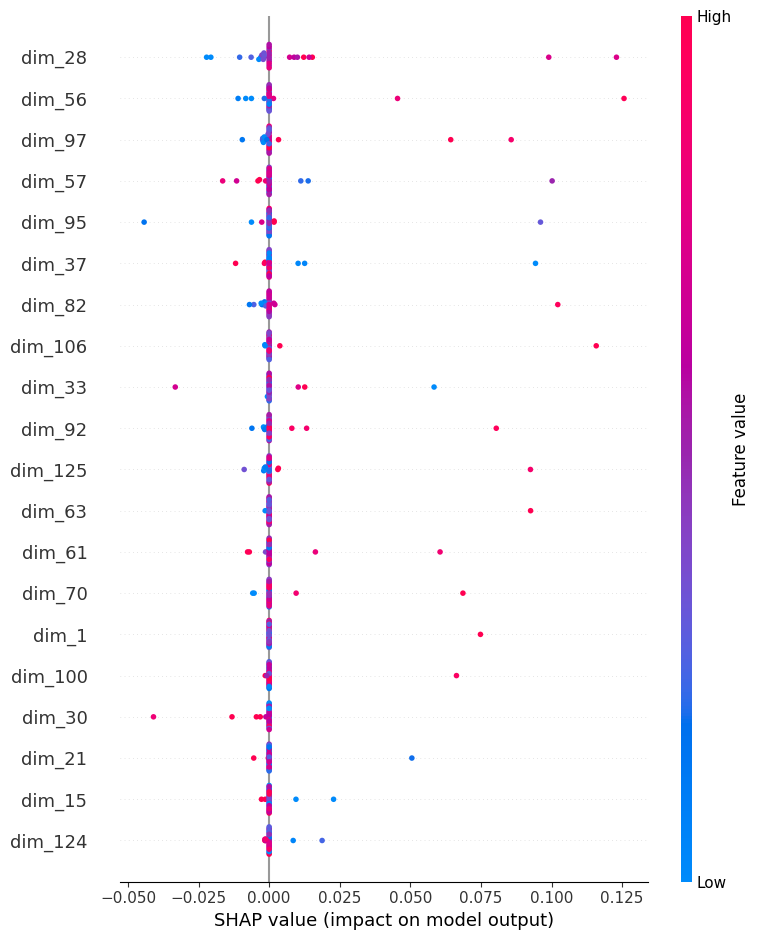

In [31]:
import shap
import numpy as np
import csv
from keras.models import load_model
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1: Load trained model
model = load_model("mlp_model_keras2.h5")

# Step 2: Load dataset.csv
features = []
labels = []

with open("dataset.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        labels.append(int(row[0]))
        features.append(np.array(row[1:], dtype=np.float32))

X = np.array(features)
y = np.array(labels)

# Step 3: Re-encode labels to match training
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Step 4: Choose background and explanation set
background = X[:370]
to_explain = X[370:]

# Step 5: Create KernelExplainer (slower but compatible with Keras)
explainer = shap.KernelExplainer(model.predict, background)

# Step 6: Compute SHAP values for class 0
shap_values = explainer.shap_values(to_explain)

# Get predicted class for first sample in explanation set
predicted_class = model.predict(to_explain).argmax(axis=1)[0]

# Fix SHAP output to match (samples, features)
shap_values_for_class = shap_values[:, :, predicted_class]  # shape: (10, 128)

# Plot
shap.summary_plot(shap_values_for_class, to_explain, feature_names=[f"dim_{i}" for i in range(128)])



In [32]:
print(shap_values.shape)
print(to_explain.shape)
print(X.shape)
print(y.shape)

(31, 128, 52)
(31, 128)
(401, 128)
(401,)


In [33]:
print("Predicted class:", predicted_class)
print("Sample true label:", y[100])


Predicted class: 15
Sample true label: 124003127


In [34]:
import pandas as pd

mean_abs_shap = np.abs(shap_values_for_class).mean(axis=0)
top_features = np.argsort(mean_abs_shap)[-10:][::-1]

df = pd.DataFrame({
    "Feature": [f"dim_{i}" for i in top_features],
    "Mean |SHAP|": mean_abs_shap[top_features]
})
print(df)


   Feature  Mean |SHAP|
0   dim_28     0.011808
1   dim_56     0.006451
2   dim_97     0.005633
3   dim_57     0.005222
4   dim_95     0.004928
5   dim_37     0.004265
6   dim_82     0.004179
7  dim_106     0.003954
8   dim_33     0.003716
9   dim_92     0.003709


In [35]:
preds = model.predict(to_explain)
print("Predictions:", preds.argmax(axis=1))

print("Prediction class counts:", np.unique(preds.argmax(axis=1), return_counts=True))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predictions: [15 46  9 24 22  2 40 44 20 43 24 46 18 15 23 39 48 27 14 32  4 25 20 14
  7 43 10 28  4 38 48]
Prediction class counts: (array([ 2,  4,  7,  9, 10, 14, 15, 18, 20, 22, 23, 24, 25, 27, 28, 32, 38,
       39, 40, 43, 44, 46, 48]), array([1, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2,
       2]))


In [36]:
# Correlate input features with output probabilities
correlation = np.corrcoef(X.T, y_encoded)[-1, :-1]
top_dims = np.argsort(np.abs(correlation))[-10:][::-1]

for i in top_dims:
    print(f"dim_{i}: corr={correlation[i]:.3f}")


dim_34: corr=0.414
dim_78: corr=-0.373
dim_127: corr=-0.285
dim_31: corr=0.276
dim_61: corr=-0.230
dim_97: corr=-0.229
dim_105: corr=-0.228
dim_93: corr=0.226
dim_5: corr=-0.216
dim_124: corr=0.213
